**TITLE** : Predictive Analytics Using Historical Data and a predictive model to forecast future trends.

**STEP** **1**: Upload Dataset

In [52]:
from google.colab import files

uploaded = files.upload()

Saving archive (2).zip to archive (2) (3).zip


**STEP** **2**: Extract ZIP File

In [53]:
import zipfile
import os

zip_path = "/content/archive (2).zip"

with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall("/content/data")

print("Files extracted:")
print(os.listdir("/content/data"))

Files extracted:
['Gold_Daily .csv', 'Gold_Yearly .csv', 'Gold_Monthly.csv']


**STEP** **3**: Load Dataset

In [54]:
import pandas as pd

path="/content/data/Gold_Daily .csv"

df=pd.read_csv(path)

df.head()

,Date,Price,Open,High,Low,Vol,Change %
0,"Dec 06, 1994",375.8,375.6,376.5,375.1,0.99K,0.0008
1,"Dec 07, 1994",376.1,377.0,377.5,375.1,1.88K,0.0008
2,"Dec 08, 1994",376.6,375.3,376.7,374.8,0.48K,0.0013
3,"Dec 09, 1994",377.0,375.6,377.0,375.5,0.38K,0.0011
4,"Dec 12, 1994",377.5,376.8,377.8,376.5,0.07K,0.0013


**STEP** **3.1** : Display information

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6886 entries, 0 to 6885
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      6886 non-null   object 
 1   Price     6886 non-null   float64
 2   Open      6886 non-null   float64
 3   High      6886 non-null   float64
 4   Low       6886 non-null   float64
 5   Vol       6886 non-null   object 
 6   Change %  6886 non-null   float64
dtypes: float64(5), object(2)
memory usage: 376.7+ KB


**STEP** **3.2** : Check missing values:

In [56]:
df.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol,0
Change %,0


**STEP** **4**: Data Cleaning

In [57]:
df=df.dropna()
df=df.drop_duplicates()

**STEP** **4.1** : Convert date column

In [58]:
df['Date']=pd.to_datetime(df['Date'])

**STEP** **4.2** : Sort values:

In [59]:
df=df.sort_values('Date')

**STEP** **5**: Exploratory Data Analysis (EDA)

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

**STEP** **5.1** : Dataset overview

In [61]:
df.describe()

,Date,Price,Open,High,Low,Change %
count,6886,6886.000000,6886.000000,6886.000000,6886.000000,6886.000000
mean,2008-08-02 01:39:57.560267264,909.824807,906.941624,910.127604,903.469021,0.000309
min,1994-12-06 00:00:00,253.000000,252.900000,252.900000,252.500000,-0.111300
25%,2001-10-15 06:00:00,376.400000,376.200000,376.700000,375.800000,-0.004500
50%,2008-09-03 12:00:00,890.900000,889.800000,899.700000,883.350000,0.000200
75%,2015-06-02 18:00:00,1359.375000,1349.925000,1352.275000,1347.700000,0.005400
max,2021-12-06 00:00:00,2115.200000,2121.700000,2121.700000,2121.700000,0.127100
std,NaN,541.516040,539.071470,541.323158,536.564722,0.012892


**STEP** **5.2** : Plot historical trend

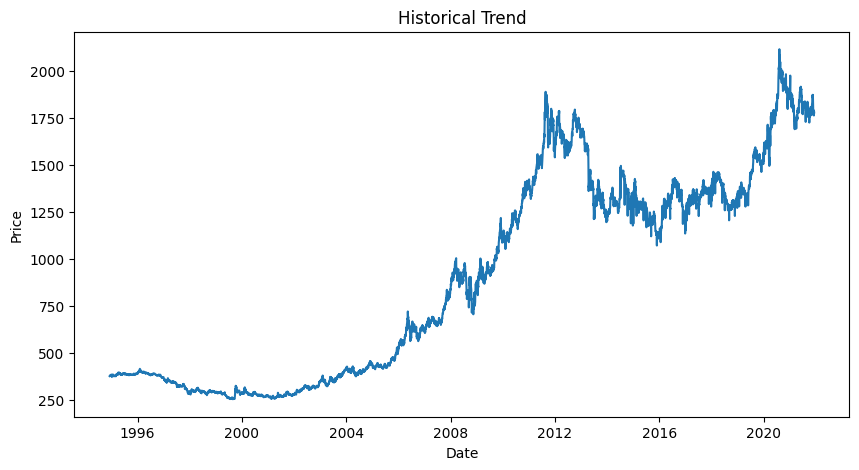

In [62]:
plt.figure(figsize=(10,5))

plt.plot(df['Date'],df['Price'])

plt.title("Historical Trend")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

**STEP** **6**: Feature Engineering

In [63]:
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.day

In [64]:
X=df[['Year','Month','Day']]

y=df['Price']

**STEP** **7**: Split Data

In [65]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**STEP** **8**: Train Prediction Model (Regression)

In [66]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

**STEP**  **8.1** : Prediction

In [67]:
pred=model.predict(X_test)

**STEP** **9**: Evaluate Model

In [68]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae=mean_absolute_error(y_test,pred)

mse=mean_squared_error(y_test,pred)

r2=r2_score(y_test,pred)

print("MAE:",mae)
print("MSE:",mse)
print("R2 Score:",r2)

MAE: 177.75759923820516
MSE: 47428.84267902265
R2 Score: 0.8357670776989993


**STEP** **10**: Visualize Prediction

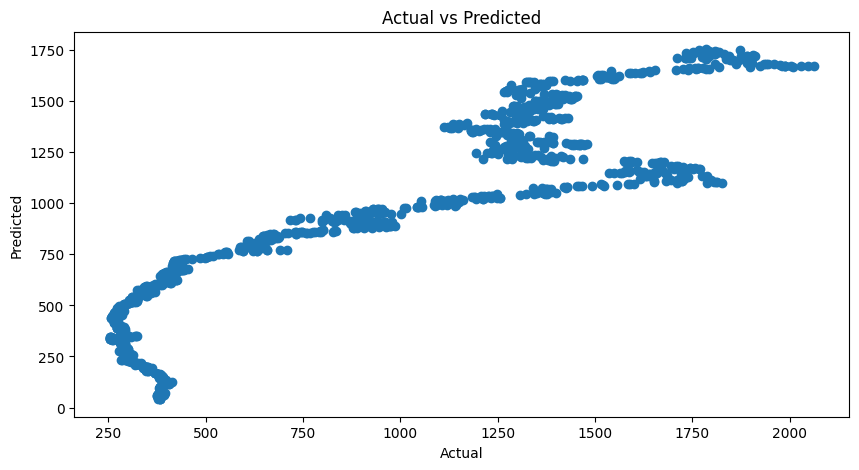

In [69]:
plt.figure(figsize=(10,5))

plt.scatter(y_test,pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

**STEP** **11**: Forecast Future Values

In [70]:
future=pd.DataFrame({
'Year':[2027,2028,2029],
'Month':[1,1,1],
'Day':[1,1,1]
})

future_pred=model.predict(future)

print(future_pred)

[2083.40679983 2146.73542499 2210.06405016]


**STEP** **12**: Save Model

In [71]:
import joblib

joblib.dump(model,"prediction_model.pkl")

['prediction_model.pkl']

**RESULT** : This project successfully demonstrated the use of predictive analytics using historical data to forecast future trends through a data-driven approach. The historical dataset was cleaned, preprocessed, and analyzed to improve data quality and model performance. Regression or time-series techniques were applied to identify patterns and generate future predictions

**CONCLUSION** : Overall, the project provided practical experience in data preprocessing, predictive modeling, forecasting, performance evaluation, and trend visualization, showing how historical data can support informed decision-making and future planning across different domains.